# Chapter 7 — Exercises

Exercises for Chapter 7 of *Bayesian Analysis with Python* (3rd edition).

## Set-up

### Imports

In [41]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats
import seaborn as sns

import const

### Defaults

In [42]:
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(const.RANDOM_SEED)

## Exercise 1 — Choosing K for a Gaussian mixture

Fit Gaussian mixtures with $K \in \{2, 3, 4\}$ to data drawn from a 3-Gaussian mixture, check convergence, then pick $K$.

### Data

Draw `N` points from a mixture of 3 Gaussians, then standardise so the priors sit on unit scale.

In [43]:
N = 400
TRUE_W = np.array([0.3, 0.5, 0.2])
TRUE_MEANS = np.array([-4.0, 0.0, 3.5])
TRUE_SIGMAS = np.array([1.1, 1.5, 0.9])

Ks = [2, 3, 4]

In [44]:
component = rng.choice(len(TRUE_W), size=N, p=TRUE_W)
data = rng.normal(TRUE_MEANS[component], TRUE_SIGMAS[component])

data_mean = data.mean()
data_sd = data.std()
z = (data - data_mean) / data_sd

[Text(0.5, 1.0, 'Synthetic data from a 3-Gaussian mixture'), Text(0.5, 0, 'x')]

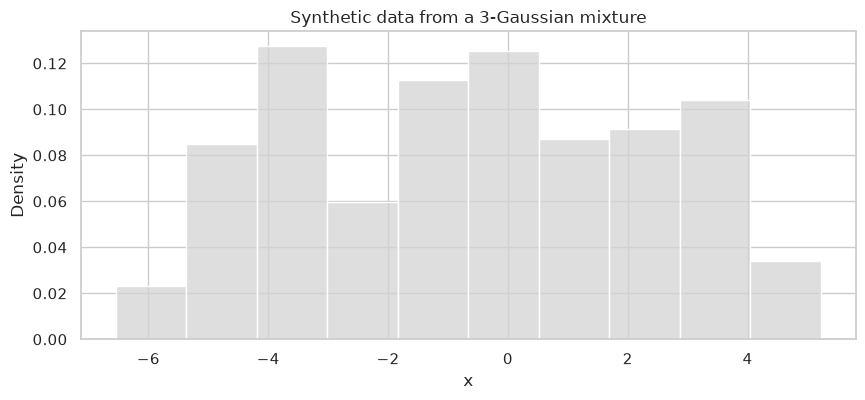

In [45]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data, stat="density", ax=ax, color="lightgray", edgecolor="white")
ax.set(title="Synthetic data from a 3-Gaussian mixture", xlabel="x")

### Fit

Marginalised `NormalMixture` per $K$, fit to the standardised data.
Ordered means break label-switching; each component learns its own `sigma`.
Unit-scale priors: `means ~ Normal(0, 1)`, `sigma ~ Exponential(1)`.

In [46]:
models = {}
idatas = {}
for K in Ks:
    coords = {"component": range(K), "obs": range(N)}
    with pm.Model(coords=coords) as model:
        # data
        y_data = pm.Data("y_data", z, dims="obs")

        # priors
        p = pm.Dirichlet("p", a=np.ones(K), dims="component")
        means = pm.Normal(
            "means", mu=0, sigma=1, dims="component",
            transform=pm.distributions.transforms.ordered,
            initval=np.linspace(-1, 1, K),
        )
        sigma = pm.Exponential("sigma", lam=1, dims="component")

        # likelihood
        y = pm.NormalMixture("y", w=p, mu=means, sigma=sigma, observed=y_data, dims="obs")

        # sample
        idata = pm.sample(
            draws=1000, chains=4, target_accept=0.99,
            tune=2000, random_seed=const.RANDOM_SEED,
        )

    idatas[K] = idata
    models[K] = model

NUTS[nutpie]: [p, means, sigma]


Output()

NUTS[nutpie]: [p, means, sigma]


Output()

NUTS[nutpie]: [p, means, sigma]


Output()

### Convergence checks

Want `r_hat < 1.01`, `ess_bulk > 400`, and zero divergences.

In [47]:
rows = {}
for K, idata in idatas.items():
    summ = az.summary(idata, var_names=["p", "means", "sigma"])
    rows[K] = {
        "max_r_hat": summ["r_hat"].max(),
        "min_ess_bulk": summ["ess_bulk"].min(),
        "divergences": int(idata.sample_stats["diverging"].sum()),
    }
checks = pd.DataFrame(rows).T
checks.index.name = "K"
checks

,max_r_hat,min_ess_bulk,divergences
K,,,
2,1.01,1294,0
3,1.00,601,0
4,1.01,187,0


### Choosing K

Posterior-mean mixture density split into weighted components (back-transformed to original units) over the data.

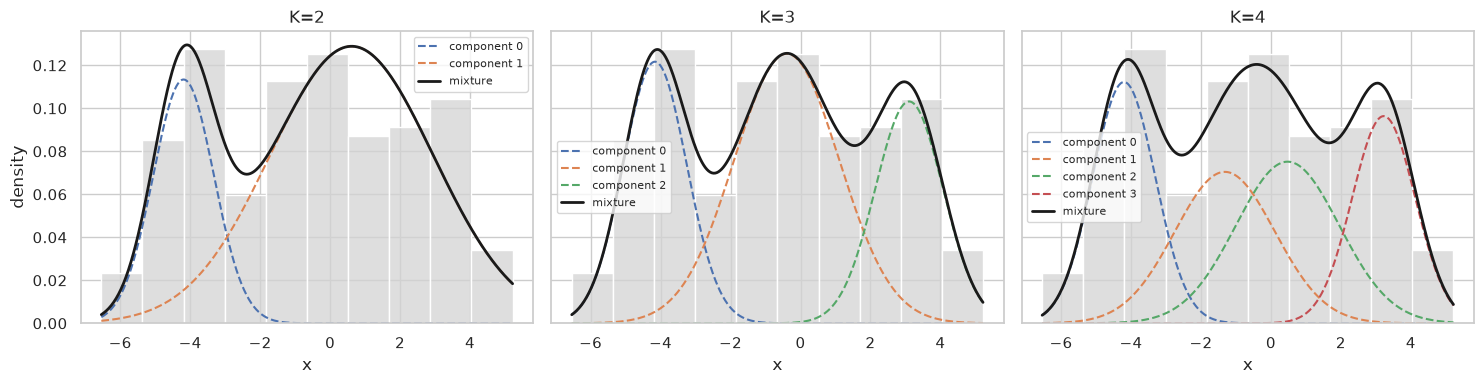

In [48]:
x = np.linspace(data.min(), data.max(), 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, (K, idata) in zip(axes, idatas.items()):
    post = idata.posterior
    p = post["p"].mean(("chain", "draw")).values
    means = data_mean + data_sd * post["means"].mean(("chain", "draw")).values
    sigma = data_sd * post["sigma"].mean(("chain", "draw")).values

    sns.histplot(data, stat="density", ax=ax, color="lightgray", edgecolor="white")

    total = np.zeros_like(x)
    for k in range(K):
        comp = p[k] * stats.norm.pdf(x, means[k], sigma[k])
        total += comp
        ax.plot(x, comp, "--", lw=1.5, label=f"component {k}")
    ax.plot(x, total, "k-", lw=2, label="mixture")
    ax.set(title=f"K={K}", xlabel="x", ylabel="density")
    ax.legend(fontsize=8)

fig.tight_layout()